# Figure 1 |  Global pattern of mangrove changes during 1980s-2023. 

The color scale, shown on the bottom left, indicates the rate of change in terms of both deforestation (red) and expansion (blue), with 0% change represented by grey. The rate is calculated as (Δarea/original area)×100%. Inset regional maps provide detailed examples of change patterns for Ecuador, the Niger Delta, Nigeria, and the Mahakam Delta, Indonesia, where blue patches indicate mangrove expansion, red patches signify deforestation, and grey patches indicate persistent mangrove areas. An online interactive map for mangrove extents and their change area is available through the following link: https://zhenzhang.users.earthengine.app/view/globalmangrovedynamic.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
from tqdm import tqdm
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [ ]:
gdf = gpd.read_file("Code_Data/Grids_1degree.shp")
gdf['Loss8410%'] = gdf['Loss8410']/gdf['Area1980s']; gdf['Gain8410%'] = gdf['Gain8410']/gdf['Area1980s']
gdf['Loss1023%'] = gdf['Loss1023']/gdf['Area2010']; gdf['Gain1023%'] = gdf['Gain1023']/gdf['Area2010']
gdf['Loss8423%'] = gdf['Loss8423']/gdf['Area1980s']; gdf['Gain8423%'] = gdf['Gain8423']/gdf['Area1980s']
gdf = gdf.drop(columns=['StartYear1','StartYear2','MidYear1','MidYear2','RGain8410','Field'])
gdf.dropna(inplace=True)
gdf.index = range(len(gdf))

baseline1984 = gpd.read_file('Code_Data/Baseline1980s_prj.shp')
baseline2010 = gpd.read_file('Code_Data/Baseline2010_prj.shp')
change8410 = gpd.read_file("Code_Data/Change1984to2010.shp")
change1023 = gpd.read_file("Code_Data/Change2010to2023.shp")
change8423 = gpd.read_file("Code_Data/Change1984to2023.shp")
# gdf

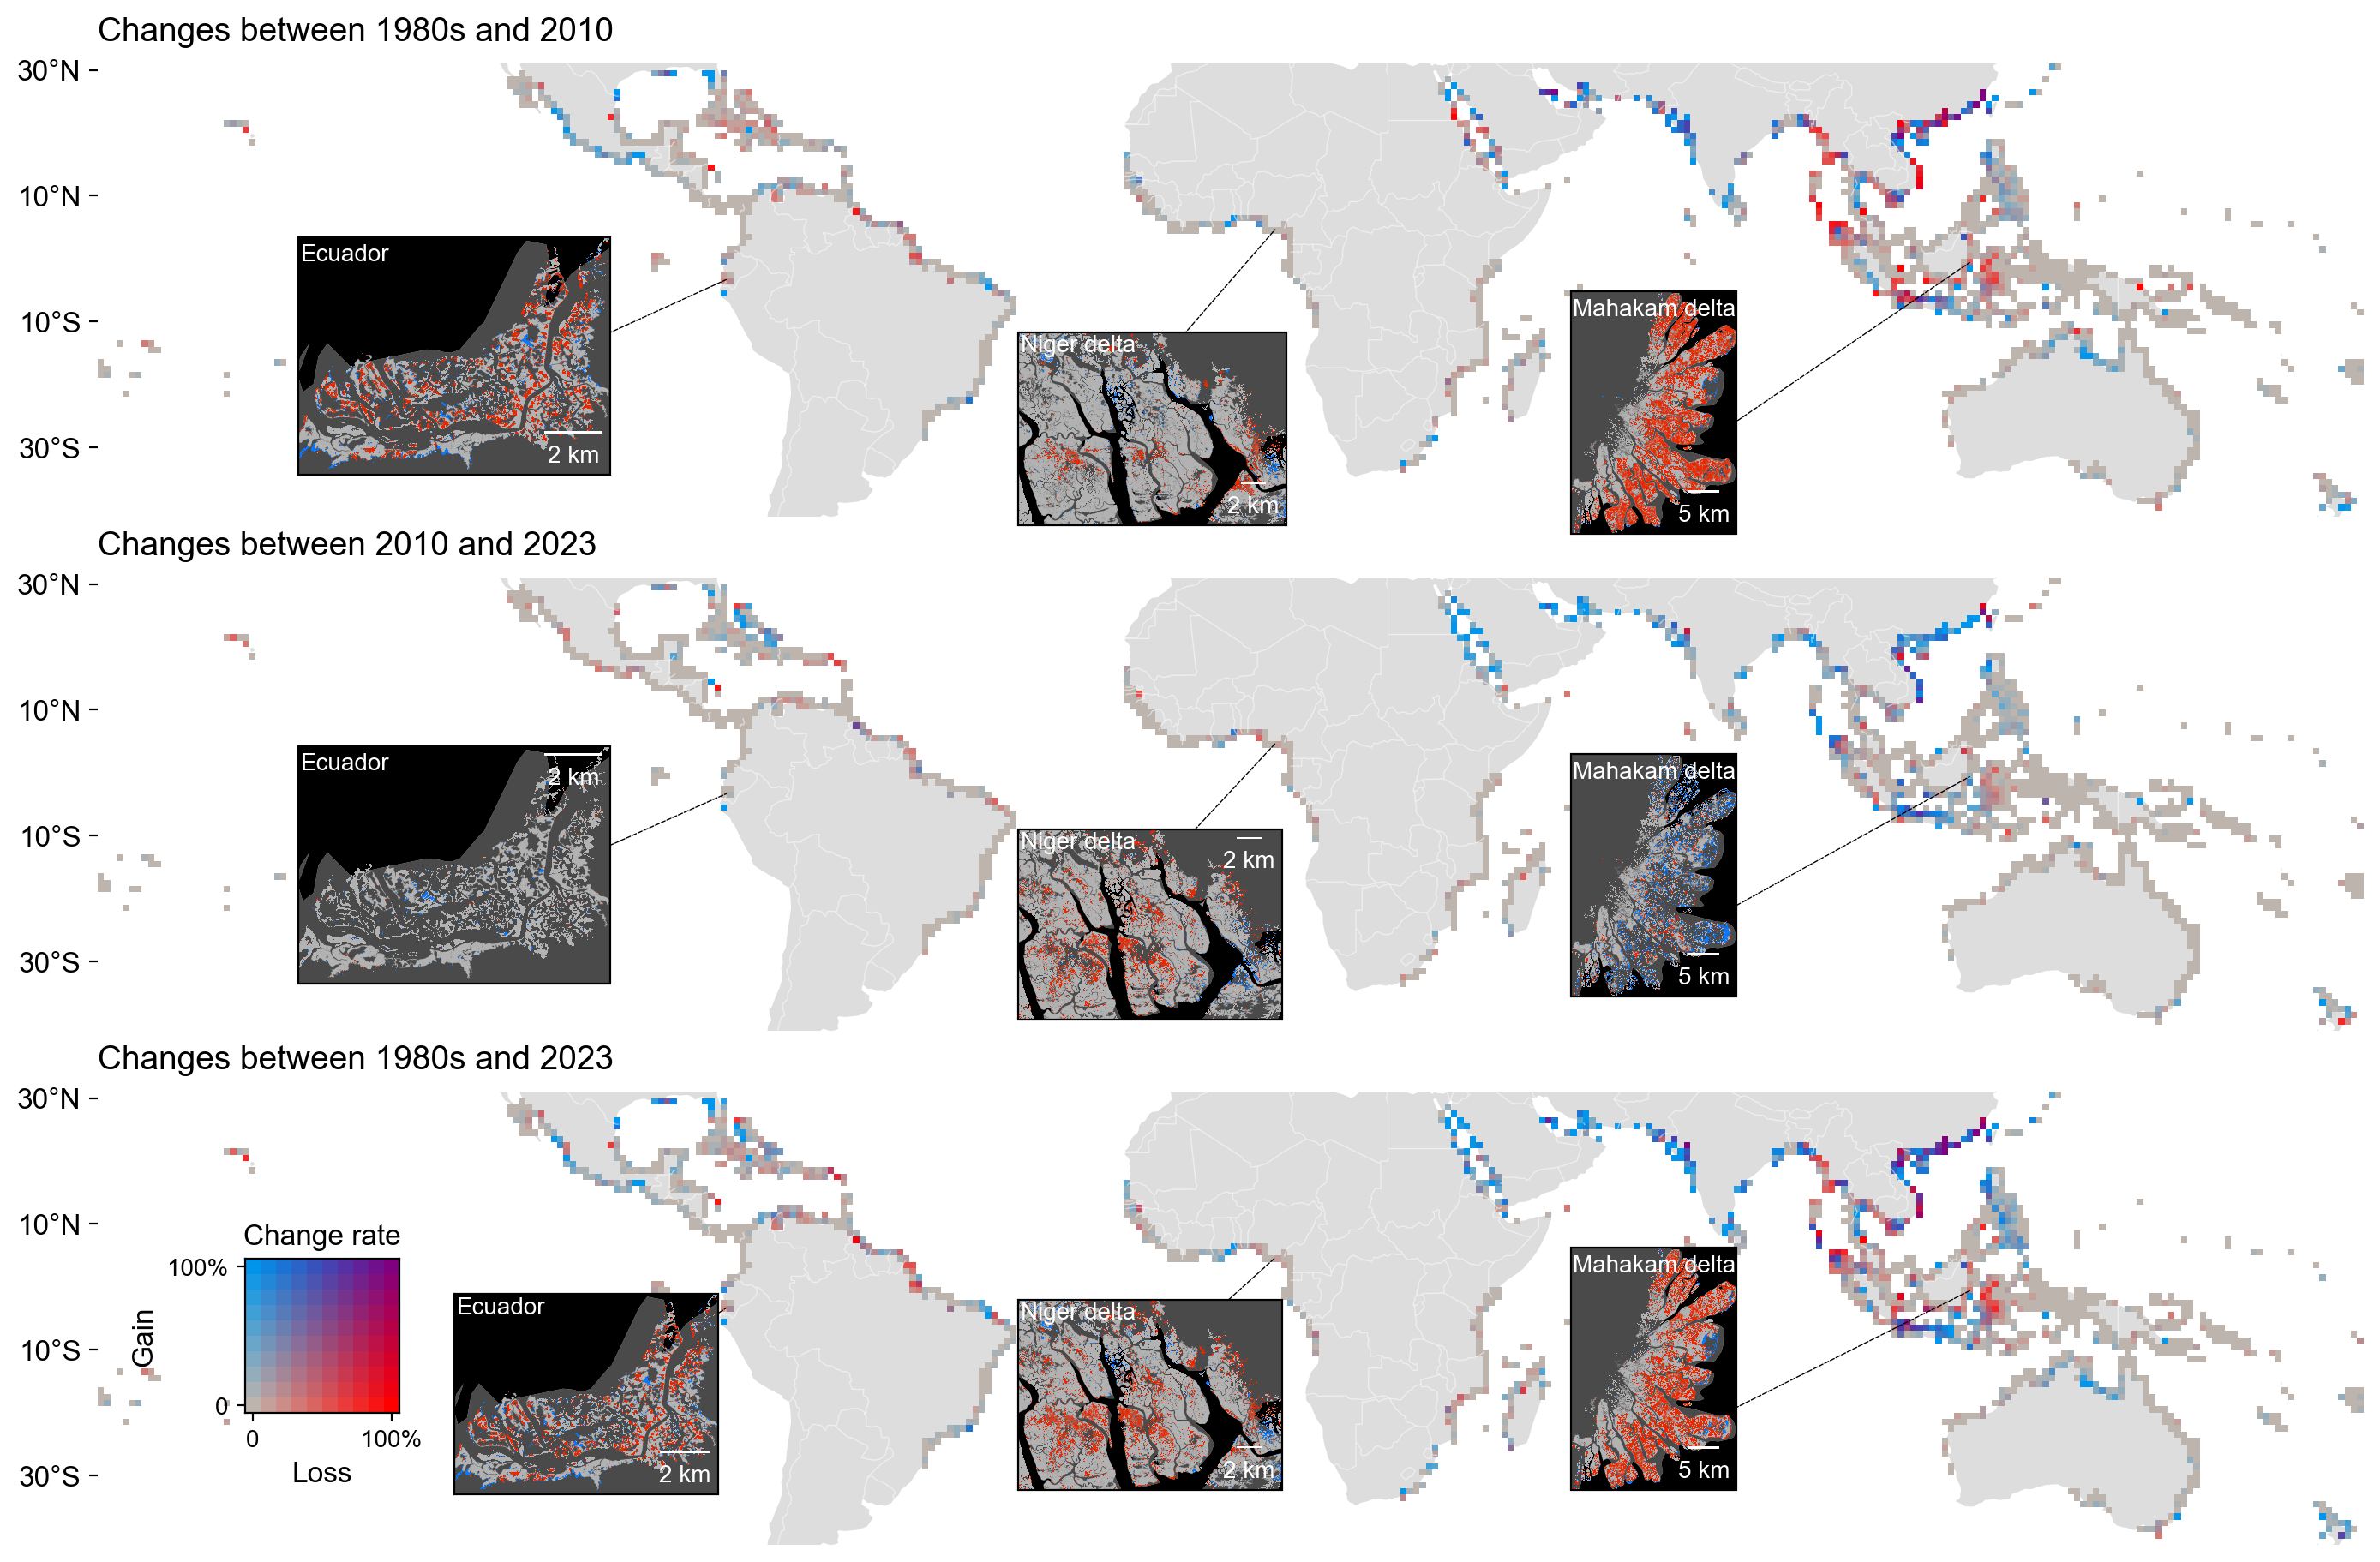

In [ ]:
def AddingInset(InsetPosition,coordinates,changelyr, baselinelyr,scaleloc,textx,texty,text,ax_global):
    from shapely.geometry import box
    from shapely.geometry.point import Point
    from matplotlib.patches import ConnectionPatch
    import cartopy.feature as cfeature
    from matplotlib_scalebar.scalebar import ScaleBar
    import math
    def haversine_custom(lat1, lon1, lat2, lon2):
        R = 6371000  
        phi1, phi2 = math.radians(lat1), math.radians(lat2)
        d_phi = math.radians(lat2 - lat1)
        d_lambda = math.radians(lon2 - lon1)

        a = math.sin(d_phi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(d_lambda/2)**2
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

        return R * c
    
    lon_min, lon_max,lat_min, lat_max = coordinates
    hw_ratio = (lon_max - lon_min) / (lat_max - lat_min)  
    InsetPosition.append(InsetPosition[-1]*hw_ratio)
    ax_inset = fig.add_axes(InsetPosition, projection=ccrs.PlateCarree())  
    ax_inset.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax_inset.add_feature(cfeature.LAND, facecolor='#4A4A4A')  
    ax_inset.add_feature(cfeature.OCEAN, facecolor='#000000') 
    changelyr.to_crs("EPSG:4326",inplace=True);baselinelyr.to_crs("EPSG:4326",inplace=True)
    bbox = box(lon_min, lat_min, lon_max, lat_max)
    bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs=changelyr.crs)
    changelyr_clipped = gpd.clip(changelyr, bbox_gdf)
    baselinelyr_clipped = gpd.clip(baselinelyr, bbox_gdf)
    baselinelyr_clipped.plot(ax=ax_inset, color='#b2b2b2', edgecolor='none')
    changelyr_clipped[changelyr_clipped['gridcode'] == 1].plot(ax=ax_inset, color='#e92700', edgecolor='none')
    changelyr_clipped[changelyr_clipped['gridcode'] == 0].plot(ax=ax_inset, color='#0978ff', edgecolor='none')
    plt.text(textx,texty,text,fontdict={'size' : 10},color='white', transform=ax_inset.transAxes)
    ax_inset.set_zorder(10)
    distance_meters = haversine_custom(lat_min, lon_max, lat_max, lon_max)
    ax_inset.add_artist(ScaleBar(distance_meters,box_color="none",color='white',location=scaleloc))

    target_lon = (lon_min + lon_max) / 2  
    target_lat = (lat_min + lat_max) / 2  
    inset_lon = lon_min
    inset_lat = lat_min
    inset_coords = (inset_lon, inset_lat)
    global_coords = (target_lon, target_lat)
    con = ConnectionPatch(
        xyA=inset_coords,  
        xyB=global_coords,  
        coordsA=ax_inset.transData,  
        coordsB=ccrs.PlateCarree()._as_mpl_transform(ax_global),  
        color='black',  
        linestyle='--',  
        linewidth=0.5,  
        zorder=2 
    )
    fig.add_artist(con)

colors = [['#beb4ae', '#FF0000'],  ['#0195eb', 'purple']]

fig = plt.figure(figsize=(14, 9),constrained_layout=True)
gs = GridSpec(nrows=3, ncols=1,figure=fig)
ax1 = fig.add_subplot(gs[0,0],projection=ccrs.PlateCarree())
plt.text(0,1.05,'Changes between 1980s and 2010',fontdict={'size' : 14},color='black', transform=ax1.transAxes)
ZhenPlot.add_basemap(ax1,xticks=False,yticks=True,fontsize=12)
ZhenPlot.BivariatePloting('Loss8410%','Gain8410%',gdf,ax1,colors,cb=0,cax=0)
AddingInset([0.12, 0.69, 0.13],[-80.32, -79.965,-3.47, -3.2],change8410,baseline1984,"lower right",0.01,0.9,'Ecuador',ax1)
AddingInset([0.42, 0.65, 0.112],[6.8, 7.317,4.43, 4.8],change8410,baseline1984,"lower right",0.01,0.9,'Niger delta',ax1)
AddingInset([0.57, 0.66, 0.23],[117.23, 117.63,-0.91, -0.325],change8410,baseline1984,"lower right",0.01,0.9,'Mahakam delta',ax1)
ax1.set_frame_on(False)

ax2 = fig.add_subplot(gs[1,0],projection=ccrs.PlateCarree())
plt.text(0,1.05,'Changes between 2010 and 2023',fontdict={'size' : 14},color='black', transform=ax2.transAxes)
ZhenPlot.add_basemap(ax2,xticks=False,yticks=True,fontsize=12)
ZhenPlot.BivariatePloting('Loss1023%','Gain1023%',gdf,ax2,colors,cb=0,cax=0)
AddingInset([0.12, 0.36, 0.13],[-80.32, -79.965,-3.47, -3.2],change1023,baseline2010,"upper right",0.01,0.9,'Ecuador',ax2)
AddingInset([0.42, 0.33, 0.11],[6.8, 7.317,4.43, 4.8],change1023,baseline2010,"upper right",0.01,0.9,'Niger delta',ax2)
AddingInset([0.57, 0.36, 0.23],[117.23, 117.63,-0.91, -0.325],change1023,baseline2010,"lower right",0.01,0.9,'Mahakam delta',ax2)
ax2.set_frame_on(False)

ax3 = fig.add_subplot(gs[2,0],projection=ccrs.PlateCarree())
plt.text(0,1.05,'Changes between 1980s and 2023',fontdict={'size' : 14},color='black', transform=ax3.transAxes)
ZhenPlot.add_basemap(ax3,xticks=False,yticks=True,fontsize=12)
cax = fig.add_axes([0.08, 0.09, 0.1, 0.1])
ZhenPlot.BivariatePloting('Loss8423%','Gain8423%',gdf,ax3,colors,cb=1,cax=cax)
cax.set_xticklabels(['0', '100%']);cax.set_yticklabels(['0', '100%'])
cax.set_title('Change rate', fontsize=12)
cax.set_xlabel('Loss',c="k", fontsize=12);cax.set_ylabel('Gain',c="k", fontsize=12)
AddingInset([0.185, 0.03, 0.11],[-80.32, -79.965,-3.47, -3.2],change8423,baseline1984,"lower right",0.01,0.9,'Ecuador',ax3)
AddingInset([0.42, 0.025, 0.11],[6.8, 7.317,4.43, 4.8],change8423,baseline1984,"lower right",0.01,0.9,'Niger delta',ax3)
AddingInset([0.57, 0.04, 0.23],[117.23, 117.63,-0.91, -0.325],change8423,baseline1984,"lower right",0.01,0.9,'Mahakam delta',ax3)
ax3.set_frame_on(False)

plt.savefig("Figures/Fig1.png", dpi=500, format='png', bbox_inches='tight')
plt.savefig("Figures/Fig1.pdf", dpi=500, format='pdf', bbox_inches='tight')